# Отчёт по экспериментам с XGBoost и LightGBM

## Проделанная работа

В рамках экспериментов с градиентным бустингом была выполнена следующая работа:

1. **RandomizedSearch для XGBoost** (30 итераций, 3 фолда) — подбор параметров: booster (gbtree, dart), max_depth, learning_rate, subsample, colsample_bytree/bylevel/bynode, reg_alpha, reg_lambda, min_child_weight, а также специфичные параметры для DART (rate_drop, skip_drop, sample_type, normalize_type)
2. **RandomizedSearch для LightGBM** (100 итераций, 5 фолдов) — подбор параметров: boosting_type (gbdt, dart, goss), n_estimators, max_depth, num_leaves, learning_rate, subsample, colsample_bytree, reg_alpha, reg_lambda, min_child_samples, min_child_weight

## Результаты моделей (валидационная выборка)

| Модель | Accuracy | F1 | Precision | Recall | ROC-AUC |
|--------|----------|-----|-----------|--------|---------|
| **XGBoost (DART)** | 0.777 | 0.354 | 0.267 | 0.527 | 0.745 |
| **LightGBM (DART)** | 0.744 | 0.353 | 0.250 | 0.603 | 0.751 |

## Сравнение с бейзлайнами

| Модель | Оптимизир. F1 |
|--------|---------------|
| **XGBoost** | 0.354 | 
| **LightGBM** | 0.353 |

## Ключевые выводы

**Обе модели показали сопоставимые результаты**

| Модель | Проблема |
|--------|----------|
| **XGBoost** | Низкий Precision (26.7%) при умеренном Recall (52.7%) — модель ошибается в предсказаниях положительного класса |
| **LightGBM** | Низкий Precision (25.0%) при хорошем Recall (60.3%) — модель агрессивно предсказывает дефолты, но с высокой долей ложных срабатываний |

### Особенности обучения

- **XGBoost**: Лучший бустер — DART (Dropouts meet Multiple Additive Regression Trees), что указывает на пользу от dropout-регуляризации
- **LightGBM**: Лучший бустер — DART, высокая регуляризация (reg_alpha=1.93, reg_lambda=1.71)
- Обе модели имеют относительно неглубокие деревья (max_depth=10-11)
- LightGBM потребовал больше деревьев (280 vs 108 для XGBoost)

## Сохранённые артефакты

| Тип | Путь |
|-----|------|
| **Метрики моделей** | `../artifacts/ExperimentBoost/runsMLP.csv` |
| **Матрицы ошибок** | `../artifacts/ExperimentBoost/figures/CmXgb.png`, `../artifacts/ExperimentBoost/figures/CmLgb.png` |
| **ROC-кривые** | `../artifacts/ExperimentBoost/figures/RocXgb.png`, `../artifacts/ExperimentBoost/figures/RocLgb.png` |
| **PR-кривые** | `../artifacts/ExperimentBoost/figures/PrXgb.png`, `../artifacts/ExperimentBoost/figures/PrLgb.png` |

## Сравнительный анализ

| Показатель | XGBoost | LightGBM |
|------------|---------|----------|
| **Лучший бустер** | DART | DART |
| **Глубина деревьев** | 11 | 10 |
| **Learning rate** | 0.0596 | 0.0146 |
| **Кол-во деревьев** | 108 | 280 |
| **Регуляризация L1** | 0.587 | 1.927 |
| **Регуляризация L2** | 0.028 | 1.706 |
| **Время обучения** | ~25 сек | ~3-4 мин |

## Заключение

Обе модели градиентного бустинга показали сопоставимые результаты с F1 0.35. DART (Dropout-регуляризация) оказался оптимальным бустером для обеих библиотек. Низкий Precision (25-27%) остаётся общей проблемой, указывая на высокую долю ложноположительных предсказаний. Для улучшения может потребоваться настройка порога классификации или использование более сложных методов балансировки классов.

In [29]:
import numpy as np
import pandas as pd
import json
import matplotlib.pyplot as plt
from scipy.stats import uniform, loguniform, randint
import xgboost as xgb
import lightgbm as lgb


from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    RocCurveDisplay,
    PrecisionRecallDisplay,
    confusion_matrix
)

In [30]:
df = pd.read_csv("../data/PROCESSED/LoanDefaultPredictionDatasetPROC.csv")
df.head()

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Default,...,HasMortgage_Yes,HasDependents_No,HasDependents_Yes,LoanPurpose_Auto,LoanPurpose_Business,LoanPurpose_Education,LoanPurpose_Home,LoanPurpose_Other,HasCoSigner_No,HasCoSigner_Yes
0,56,85994,50587,520,80,4,15.23,36,0.44,0,...,1,0,1,0,0,0,0,1,0,1
1,69,50432,124440,458,15,1,4.81,60,0.68,0,...,0,1,0,0,0,0,0,1,0,1
2,46,84208,129188,451,26,3,21.17,24,0.31,1,...,1,0,1,1,0,0,0,0,1,0
3,32,31713,44799,743,0,3,7.07,24,0.23,0,...,0,1,0,0,1,0,0,0,1,0
4,60,20437,9139,633,8,4,6.51,48,0.73,0,...,0,0,1,1,0,0,0,0,1,0


In [ ]:
X = df.drop("Default", axis=1)
y = df["Default"]

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print("Размеры выборок:")
print("train:", X_train.shape)
print("val:", X_val.shape)
print("test:", X_test.shape)

print("\nРаспределение классов (train):")
print(y_train.value_counts(normalize=True))
print("\nРаспределение классов (val):")
print(y_val.value_counts(normalize=True))
print("\nРаспределение классов (test):")
print(y_test.value_counts(normalize=True))

Размеры выборок:
train: (178742, 31)
val: (38302, 31)
test: (38303, 31)

Распределение классов (train):
Default
0    0.883872
1    0.116128
Name: proportion, dtype: float64

Распределение классов (val):
Default
0    0.88387
1    0.11613
Name: proportion, dtype: float64

Распределение классов (test):
Default
0    0.883873
1    0.116127
Name: proportion, dtype: float64


In [32]:
scale_pos_weight = len(y_train[y_train == 0]) / len(y_train[y_train == 1])

xgb_model = xgb.XGBClassifier(
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss',
    n_jobs=-1,
    scale_pos_weight=scale_pos_weight
)

# Параметры для поиска
param_distributions_xgb = {
    # Количество деревьев
    'n_estimators': randint(100, 500),
    
    # Максимальная глубина
    'max_depth': randint(3, 12),
    
    # Learning rate
    'learning_rate': uniform(0.01, 0.3),
    
    # Субдискретизация по строкам
    'subsample': uniform(0.6, 0.4),
    
    # Субдискретизация по колонкам
    'colsample_bytree': uniform(0.6, 0.4),
    'colsample_bylevel': uniform(0.6, 0.4),
    'colsample_bynode': uniform(0.6, 0.4),
    
    # Регуляризация
    'reg_alpha': uniform(0, 2),    # L1
    'reg_lambda': uniform(0, 2),   # L2
    
    # Минимальный вес в листе (борьба с дисбалансом)
    'min_child_weight': randint(1, 10),
    
    # Тип бустинга
    'booster': ['gbtree', 'dart'],
    
    # Параметры для dart
    'sample_type': ['uniform', 'weighted'],
    'normalize_type': ['tree', 'forest'],
    'rate_drop': uniform(0, 0.5),
    'skip_drop': uniform(0, 0.5),
}

# Случайный поиск
random_search_xgb = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_distributions_xgb,
    n_iter=30,
    scoring='f1',
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
    n_jobs=1,
    random_state=42,
    verbose=2,
    return_train_score=True
)


random_search_xgb.fit(X_train, y_train)

print("Лучшие параметры XGBoost:")
print(random_search_xgb.best_params_)
print(f"Лучший F1: {random_search_xgb.best_score_:.4f}")

# Результаты на валидации
best_xgb = random_search_xgb.best_estimator_
y_pred = best_xgb.predict(X_val)
y_proba = best_xgb.predict_proba(X_val)[:, 1]



Fitting 3 folds for each of 30 candidates, totalling 90 fits


d:\study\aie_std\AIEngineering_CoursMIREA\project\.venv\Lib\site-packages\xgboost\core.py:160: UserWarning: [12:22:31] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0b3782d1791676daf-1\xgboost\xgboost-ci-windows\src\learner.cc:742: 
Parameters: { "normalize_type", "rate_drop", "sample_type", "skip_drop" } are not used.

  warnings.warn(smsg, UserWarning)


[CV] END booster=gbtree, colsample_bylevel=0.9186171947440931, colsample_bynode=0.6733739159464655, colsample_bytree=0.9118764001091078, learning_rate=0.1890550473839461, max_depth=5, min_child_weight=7, n_estimators=430, normalize_type=tree, rate_drop=0.4330880728874676, reg_alpha=1.2022300234864176, reg_lambda=1.416145155592091, sample_type=weighted, skip_drop=0.028205789513550128, subsample=0.8887995089067299; total time=   0.7s


d:\study\aie_std\AIEngineering_CoursMIREA\project\.venv\Lib\site-packages\xgboost\core.py:160: UserWarning: [12:22:32] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0b3782d1791676daf-1\xgboost\xgboost-ci-windows\src\learner.cc:742: 
Parameters: { "normalize_type", "rate_drop", "sample_type", "skip_drop" } are not used.

  warnings.warn(smsg, UserWarning)


[CV] END booster=gbtree, colsample_bylevel=0.9186171947440931, colsample_bynode=0.6733739159464655, colsample_bytree=0.9118764001091078, learning_rate=0.1890550473839461, max_depth=5, min_child_weight=7, n_estimators=430, normalize_type=tree, rate_drop=0.4330880728874676, reg_alpha=1.2022300234864176, reg_lambda=1.416145155592091, sample_type=weighted, skip_drop=0.028205789513550128, subsample=0.8887995089067299; total time=   0.7s


d:\study\aie_std\AIEngineering_CoursMIREA\project\.venv\Lib\site-packages\xgboost\core.py:160: UserWarning: [12:22:33] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0b3782d1791676daf-1\xgboost\xgboost-ci-windows\src\learner.cc:742: 
Parameters: { "normalize_type", "rate_drop", "sample_type", "skip_drop" } are not used.

  warnings.warn(smsg, UserWarning)


[CV] END booster=gbtree, colsample_bylevel=0.9186171947440931, colsample_bynode=0.6733739159464655, colsample_bytree=0.9118764001091078, learning_rate=0.1890550473839461, max_depth=5, min_child_weight=7, n_estimators=430, normalize_type=tree, rate_drop=0.4330880728874676, reg_alpha=1.2022300234864176, reg_lambda=1.416145155592091, sample_type=weighted, skip_drop=0.028205789513550128, subsample=0.8887995089067299; total time=   0.7s
[CV] END booster=dart, colsample_bylevel=0.6849356442713105, colsample_bynode=0.6727299868828402, colsample_bytree=0.6733618039413735, learning_rate=0.1012726728878613, max_depth=8, min_child_weight=9, n_estimators=148, normalize_type=tree, rate_drop=0.30592644736118974, reg_alpha=0.27898772130408367, reg_lambda=0.5842892970704363, sample_type=weighted, skip_drop=0.11638567021515211, subsample=0.6362425738131283; total time=  29.2s
[CV] END booster=dart, colsample_bylevel=0.6849356442713105, colsample_bynode=0.6727299868828402, colsample_bytree=0.67336180394

KeyboardInterrupt: 

In [ ]:
# Базовая модель
lgb_model = lgb.LGBMClassifier(
    random_state=42,
    verbose=-1,
    n_jobs=-1,
    scale_pos_weight=scale_pos_weight
)

# Параметры для поиска
param_distributions_lgb = {
    # Количество деревьев
    'n_estimators': randint(100, 1000),
    
    # Максимальная глубина
    'max_depth': randint(3, 15),
    'num_leaves': randint(10, 150),  # LightGBM специфичный параметр
    
    # Learning rate
    'learning_rate': uniform(0.01, 0.3),
    
    # Субдискретизация
    'subsample': uniform(0.6, 0.4),
    'subsample_freq': randint(1, 10),
    
    # Субдискретизация по колонкам
    'colsample_bytree': uniform(0.6, 0.4),
    
    # Регуляризация
    'reg_alpha': uniform(0, 2),
    'reg_lambda': uniform(0, 2),
    
    # Минимальное количество данных в листе
    'min_child_samples': randint(5, 50),
    'min_child_weight': uniform(0, 0.1),
    
    # Тип бустинга
    'boosting_type': ['gbdt', 'dart', 'goss'],
    
}

random_search_lgb = RandomizedSearchCV(
    estimator=lgb_model,
    param_distributions=param_distributions_lgb,
    n_iter=100,
    scoring='f1',
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    n_jobs=1,
    random_state=42,
    verbose=2,
    return_train_score=True
)

random_search_lgb.fit(X_train, y_train)

print("Лучшие параметры LightGBM:")
print(random_search_lgb.best_params_)
print(f"Лучший F1: {random_search_lgb.best_score_:.4f}")

# Результаты на валидации
best_lgb = random_search_lgb.best_estimator_
y_pred = best_lgb.predict(X_val)
y_proba = best_lgb.predict_proba(X_val)[:, 1]



Fitting 5 folds for each of 100 candidates, totalling 500 fits
[CV] END boosting_type=goss, colsample_bytree=0.9186171947440931, learning_rate=0.06503043695984914, max_depth=10, min_child_samples=25, min_child_weight=0.015601864044243652, n_estimators=566, num_leaves=84, reg_alpha=0.9184977839317343, reg_lambda=0.6674172222780437, subsample=0.6571467271687763, subsample_freq=3; total time=   0.0s
[CV] END boosting_type=goss, colsample_bytree=0.9186171947440931, learning_rate=0.06503043695984914, max_depth=10, min_child_samples=25, min_child_weight=0.015601864044243652, n_estimators=566, num_leaves=84, reg_alpha=0.9184977839317343, reg_lambda=0.6674172222780437, subsample=0.6571467271687763, subsample_freq=3; total time=   0.1s
[CV] END boosting_type=goss, colsample_bytree=0.9186171947440931, learning_rate=0.06503043695984914, max_depth=10, min_child_samples=25, min_child_weight=0.015601864044243652, n_estimators=566, num_leaves=84, reg_alpha=0.9184977839317343, reg_lambda=0.66741722227

d:\study\aie_std\AIEngineering_CoursMIREA\project\.venv\Lib\site-packages\sklearn\model_selection\_validation.py:425: FitFailedWarning: 
180 fits failed out of a total of 500.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
180 fits failed with the following error:
Traceback (most recent call last):
  File "d:\study\aie_std\AIEngineering_CoursMIREA\project\.venv\Lib\site-packages\sklearn\model_selection\_validation.py", line 729, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "d:\study\aie_std\AIEngineering_CoursMIREA\project\.venv\Lib\site-packages\lightgbm\sklearn.py", line 1142, in fit
    super().fit(
  File "d:\study\aie_std\AIEngineering_CoursMIREA\project\.venv\Lib\site-packages\lightgbm\sklearn.py", li

Лучшие параметры LightGBM:
{'boosting_type': 'dart', 'colsample_bytree': 0.7480634801021777, 'learning_rate': 0.01463698495866023, 'max_depth': 10, 'min_child_samples': 33, 'min_child_weight': 0.04281841483173143, 'n_estimators': 280, 'num_leaves': 104, 'reg_alpha': 1.9272399541785057, 'reg_lambda': 1.7060189109347201, 'subsample': 0.7177795568278342, 'subsample_freq': 5}
Лучший F1: 0.3479


In [ ]:
def compute_metrics(y_true, y_pred, y_proba=None):
    methrics = {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "f1": float(f1_score(y_true, y_pred)),
        "Precision": float(precision_score(y_val, y_pred, zero_division=0)),
        "Recall": float(recall_score(y_val, y_pred, zero_division=0)),
    }
    if y_proba is None:
        methrics["roc_auc"] = None
    else:
        try:
            methrics["roc_auc"] = float(roc_auc_score(y_true, y_proba))
        except Exception:
            methrics["roc_auc"] = None
    return methrics

def evaluate_on_test(model, X_test, y_test, label):
    pred = model.predict(X_test)
    proba = None
    if hasattr(model, "predict_proba"):
        proba = model.predict_proba(X_test)[:, 1]
    methrics = compute_metrics(y_test, pred, proba)
    methrics["model"] = label
    return methrics

runsExpB = []

runsExpB.append(evaluate_on_test(best_xgb, X_val, y_val, "Xgb"))
runsExpB.append(evaluate_on_test(best_lgb, X_val, y_val, "Lgb"))

for i in runsExpB:
    print(i)

{'accuracy': 0.7767479504986685, 'f1': 0.35430038510911427, 'Precision': 0.2667424673109721, 'Recall': 0.5274280575539568, 'roc_auc': 0.7450202610405325, 'model': 'Xgb'}
{'accuracy': 0.7435381964388282, 'f1': 0.3531968130638045, 'Precision': 0.24974392401527143, 'Recall': 0.6029676258992805, 'roc_auc': 0.7509844962689978, 'model': 'Lgb'}


In [ ]:
def save_metrics_to_csv(metrics_list, filepath):
    # Создаём DataFrame из списка
    df_metrics = pd.DataFrame(metrics_list)
    
    # Сортируем по ROC-AUC (опционально)
    df_metrics = df_metrics.sort_values('f1', ascending=False)
        
    # Сохраняем в CSV
    df_metrics.to_csv(filepath, index=False)
    print("ГОТОВО!")

save_metrics_to_csv(runsExpB, "../artifacts/ExperimentBoost/runsMLP.csv")

ГОТОВО!


In [ ]:
print("XGB", classification_report(y_val,  best_xgb.predict(X_val), target_names=["Не дефолт", "Дефолт"]), sep='\n')
print("LGB", classification_report(y_val,  best_lgb.predict(X_val), target_names=["Не дефолт", "Дефолт"]), sep='\n')


XGB
              precision    recall  f1-score   support

   Не дефолт       0.93      0.81      0.87     33854
      Дефолт       0.27      0.53      0.35      4448

    accuracy                           0.78     38302
   macro avg       0.60      0.67      0.61     38302
weighted avg       0.85      0.78      0.81     38302

LGB
              precision    recall  f1-score   support

   Не дефолт       0.94      0.76      0.84     33854
      Дефолт       0.25      0.60      0.35      4448

    accuracy                           0.74     38302
   macro avg       0.59      0.68      0.60     38302
weighted avg       0.86      0.74      0.78     38302



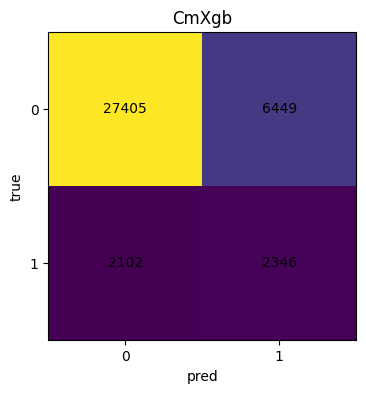

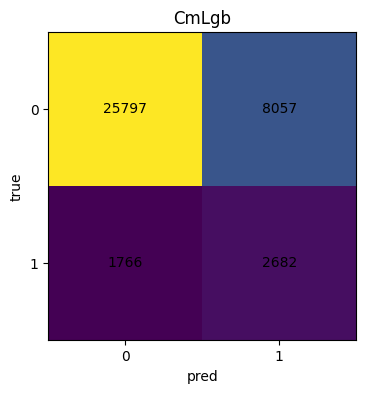

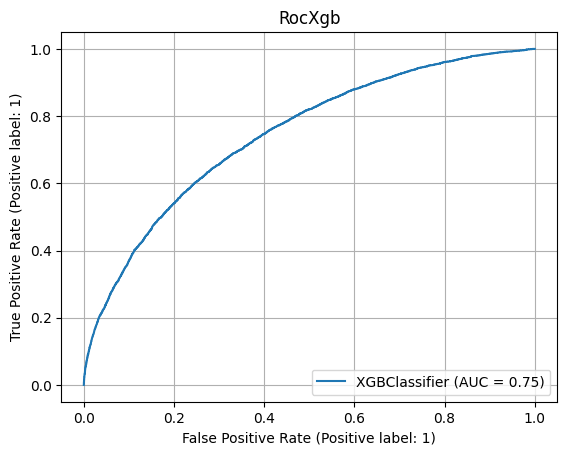

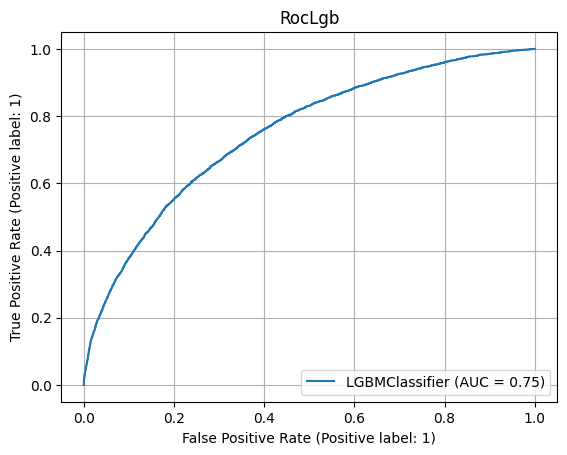

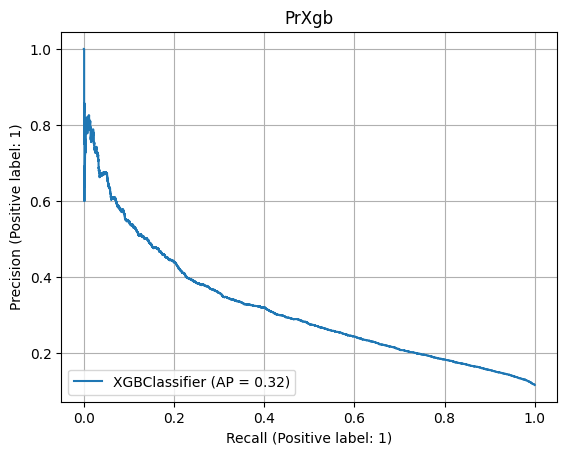

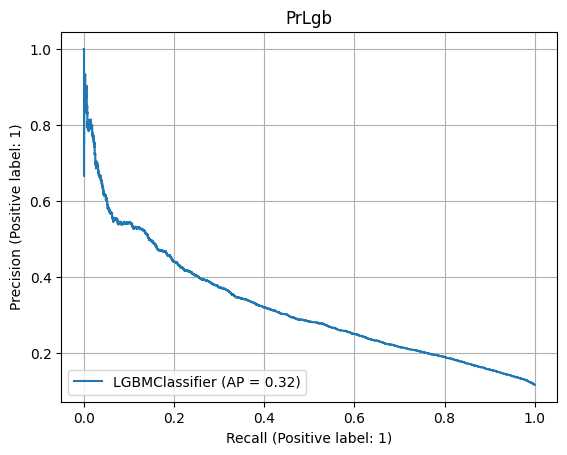

In [ ]:
#рисует матрицу ошибок
def plot_confusion(y_true, y_pred, title: str):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    plt.imshow(cm)
    plt.title(title)
    plt.xlabel("pred")
    plt.ylabel("true")
    plt.xticks([0, 1])
    plt.yticks([0, 1])
    for (i, j), v in np.ndenumerate(cm):
        plt.text(j, i, str(v), ha="center", va="center")
    pth = f"../artifacts/ExperimentBoost/figures/{title}.png"
    plt.savefig(pth)
    plt.show()

#рисует roc кривую
def plot_roc(model, X_test, y_test, title: str):
    if not hasattr(model, "predict_proba"):
        print("ROC: модель не поддерживает predict_proba")
        return
    RocCurveDisplay.from_estimator(model, X_test, y_test)
    plt.title(title)
    plt.grid(True)
    pth = f"../artifacts/ExperimentBoost/figures/{title}.png"
    plt.savefig(pth)
    plt.show()

def plot_prd(model, X_test, y_test, title):
    if not hasattr(model, "predict_proba"):
        print("PrecisionRecallDisplay: модель не поддерживает predict_proba")
        return
    PrecisionRecallDisplay.from_estimator(model, X_test, y_test)
    plt.title(title)
    plt.grid(True)
    pth = f"../artifacts/ExperimentBoost/figures/{title}.png"
    plt.savefig(pth)
    plt.show()

plot_confusion(y_val, best_xgb.predict(X_val), "CmXgb")
plot_confusion(y_val, best_lgb.predict(X_val), "CmLgb")

plot_roc(best_xgb, X_val, y_val, "RocXgb")
plot_roc(best_lgb, X_val, y_val, "RocLgb")

plot_prd(best_xgb, X_val, y_val, "PrXgb")
plot_prd(best_lgb, X_val, y_val, "PrLgb")


In [ ]:
# Основная конфигурация эксперимента
EXPERIMENT_BOOST_CONFIG = {
    "data_path": "../data/PROCESSED/LoanDefaultPredictionDatasetPROC.csv",
    "target_column": "Default",
    "random_state": 42,
    "test_size": 0.3,
    "val_size": 0.5,  # 50% от test_size (0.3 * 0.5 = 0.15 от общего датасета)
    "stratify": True,
    "scale_pos_weight": "auto",
    "description": "Gradient Boosting models (XGBoost, LightGBM) for binary classification with class imbalance"
}

# Конфигурация XGBoost (оптимизированная)
XGBOOST_OPTIMIZED_CONFIG = {
    "model_name": "XGBoostOptimized",
    "is_sklearn_like": True,
    "params": {
        "booster": "dart",
        "colsample_bylevel": 0.8428136990746738,
        "colsample_bynode": 0.7103996728090174,
        "colsample_bytree": 0.718509402281633,
        "learning_rate": 0.05958008171890075,
        "max_depth": 11,
        "min_child_weight": 7,
        "n_estimators": 108,
        "normalize_type": "forest",
        "rate_drop": 0.19744075908778486,
        "reg_alpha": 0.5869763494360762,
        "reg_lambda": 0.02815964543016891,
        "sample_type": "uniform",
        "skip_drop": 0.35342867192380856,
        "subsample": 0.8916028672163949,
        "random_state": 42,
        "use_label_encoder": False,
        "eval_metric": "logloss",
        "n_jobs": -1
    }
}

# Конфигурация LightGBM (оптимизированная)
LIGHTGBM_OPTIMIZED_CONFIG = {
    "model_name": "LightGBMOptimized",
    "is_sklearn_like": True,
    "params": {
        "boosting_type": "dart",
        "colsample_bytree": 0.7480634801021777,
        "learning_rate": 0.01463698495866023,
        "max_depth": 10,
        "min_child_samples": 33,
        "min_child_weight": 0.04281841483173143,
        "n_estimators": 280,
        "num_leaves": 104,
        "reg_alpha": 1.9272399541785057,
        "reg_lambda": 1.7060189109347201,
        "subsample": 0.7177795568278342,
        "subsample_freq": 5,
        "random_state": 42,
        "verbose": -1,
        "n_jobs": -1
    }
}

# Параметры для Random Search XGBoost
XGBOOST_RANDOM_SEARCH_PARAMS = {
    "n_iter": 30,
    "cv": 3,
    "scoring": "f1",
    "param_distributions": {
        "n_estimators": "randint(100, 500)",
        "max_depth": "randint(3, 12)",
        "learning_rate": "uniform(0.01, 0.3)",
        "subsample": "uniform(0.6, 0.4)",
        "colsample_bytree": "uniform(0.6, 0.4)",
        "colsample_bylevel": "uniform(0.6, 0.4)",
        "colsample_bynode": "uniform(0.6, 0.4)",
        "reg_alpha": "uniform(0, 2)",
        "reg_lambda": "uniform(0, 2)",
        "min_child_weight": "randint(1, 10)",
        "booster": ["gbtree", "dart"],
        "sample_type": ["uniform", "weighted"],
        "normalize_type": ["tree", "forest"],
        "rate_drop": "uniform(0, 0.5)",
        "skip_drop": "uniform(0, 0.5)"
    }
}

# Параметры для Random Search LightGBM
LIGHTGBM_RANDOM_SEARCH_PARAMS = {
    "n_iter": 100,
    "cv": 5,
    "scoring": "f1",
    "param_distributions": {
        "n_estimators": "randint(100, 1000)",
        "max_depth": "randint(3, 15)",
        "num_leaves": "randint(10, 150)",
        "learning_rate": "uniform(0.01, 0.3)",
        "subsample": "uniform(0.6, 0.4)",
        "subsample_freq": "randint(1, 10)",
        "colsample_bytree": "uniform(0.6, 0.4)",
        "reg_alpha": "uniform(0, 2)",
        "reg_lambda": "uniform(0, 2)",
        "min_child_samples": "randint(5, 50)",
        "min_child_weight": "uniform(0, 0.1)",
        "boosting_type": ["gbdt", "dart", "goss"]
    },
    "notes": {
        "warnings": "GOSS + bagging (subsample) несовместимы — часть комбинаций завершалась с ошибкой"
    }
}

# Сводный словарь со всеми конфигурациями эксперимента
ALL_BOOST_EXPERIMENTS_CONFIG = {
    "experiment": EXPERIMENT_BOOST_CONFIG,
    "random_search_params": {
        "xgboost": XGBOOST_RANDOM_SEARCH_PARAMS,
        "lightgbm": LIGHTGBM_RANDOM_SEARCH_PARAMS
    },
    "models": {
        "xgboost_optimized": XGBOOST_OPTIMIZED_CONFIG,
        "lightgbm_optimized": LIGHTGBM_OPTIMIZED_CONFIG
    },
    "evaluation_metrics": [
        "accuracy",
        "f1_score",
        "precision",
        "recall",
        "roc_auc"
    ],
    "outputs": {
        "metrics_csv": "../artifacts/ExperimentBoost/runsMLP.csv",
        "figures_directory": "../artifacts/ExperimentBoost/figures",
        "figures": [
            {
                "name": "CmXgb.png",
                "type": "confusion_matrix",
                "title": "CmXgb"
            },
            {
                "name": "CmLgb.png",
                "type": "confusion_matrix",
                "title": "CmLgb"
            },
            {
                "name": "RocXgb.png",
                "type": "roc_curve",
                "title": "RocXgb"
            },
            {
                "name": "RocLgb.png",
                "type": "roc_curve",
                "title": "RocLgb"
            },
            {
                "name": "PrXgb.png",
                "type": "pr_curve",
                "title": "PrXgb"
            },
            {
                "name": "PrLgb.png",
                "type": "pr_curve",
                "title": "PrLgb"
            }
        ]
    },
    "model_comparison_summary": {
        "best_f1": 0.3543,
        "best_model": "XGBoost",
        "common_characteristics": [
            "Обе модели используют DART бустер",
            "Умеренная глубина деревьев (10-11 уровней)",
            "Низкий Precision (~25-27%) при умеренном/высоком Recall"
        ]
    },
    "training_notes": {
        "xgboost": {
            "best_f1_cv": 0.3502,
            "best_params_found": True,
            "warnings": "Параметры DART игнорировались для gbtree"
        },
        "lightgbm": {
            "best_f1_cv": 0.3479,
            "best_params_found": True,
            "failed_fits": 180,
            "failure_reason": "Cannot use bagging in GOSS"
        }
    }
}

# Сохраняем общий конфиг
with open("../configs/experimentBoost_config.json", "w") as f:
    json.dump(ALL_BOOST_EXPERIMENTS_CONFIG, f, indent=4)

print("Конфигурация эксперимента с бустингом сохранена в ../configs/experimentBoost_config.json")

Конфигурация эксперимента с бустингом сохранена в ../configs/experimentBoost_config.json
